## 讀取資料

In [43]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

EVENT_DATA_PATH = PROJECT_ROOT / "data" / "research" / "high_dividend_ex_dividend_event_data.csv"
EVENT_SUMMARY_PATH = PROJECT_ROOT / "data" / "research" / "high_dividend_ex_dividend_event_summary.csv"
PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"

event_data = pd.read_csv(
    EVENT_DATA_PATH,
    dtype={"symbol": str},
)

event_summary = pd.read_csv(
    EVENT_SUMMARY_PATH,
    dtype={"symbol": str},
)

panel_all = pd.read_csv(
    PANEL_PATH,
    dtype={"symbol": str},
)

date_cols = [
    "date",
    "ex_date",
    "record_date",
    "pay_date",
]

for col in date_cols:
    if col in event_data.columns:
        event_data[col] = pd.to_datetime(event_data[col], errors="coerce")

for col in ["ex_date"]:
    if col in event_summary.columns:
        event_summary[col] = pd.to_datetime(event_summary[col], errors="coerce")

panel_all["date"] = pd.to_datetime(panel_all["date"])
panel_all["symbol"] = panel_all["symbol"].astype(str)

event_data["symbol"] = event_data["symbol"].astype(str)
event_summary["symbol"] = event_summary["symbol"].astype(str)

event_data = event_data.sort_values(["event_id", "relative_day"]).reset_index(drop=True)

print("Event data shape:", event_data.shape)
print("Event count:", event_data["event_id"].nunique())
print("Event symbols:", sorted(event_data["symbol"].unique()))

event_data.head()

Event data shape: (17688, 21)
Event count: 88
Event symbols: ['0056', '00713', '00878', '00919', '00929']


,event_id,symbol,etf_name,ex_date,record_date,pay_date,dividend,relative_day,date,open,...,adj_close,volume,nav,premium_discount,event_start_price,cum_return_from_start,daily_return,return_vs_day_minus_1,pre_event_volume_median,volume_ratio
0,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-100,2016-06-03,22.070000,...,10.687209,2729288,22.21,-0.0081,10.687209,0.000000,NaN,-0.130966,2638413.0,1.034443
1,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-99,2016-06-04,22.190001,...,10.764828,0,22.19,-0.0063,10.687209,0.007263,0.007263,-0.124655,2638413.0,0.000000
2,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-98,2016-06-06,22.059999,...,10.662951,2688011,22.12,-0.0063,10.687209,-0.002270,-0.009464,-0.132939,2638413.0,1.018798
3,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-97,2016-06-07,22.030001,...,10.813339,6829710,22.48,-0.0085,10.687209,0.011802,0.014104,-0.120710,2638413.0,2.588567
4,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-96,2016-06-08,22.320000,...,10.847299,3863745,22.54,-0.0080,10.687209,0.014980,0.003141,-0.117948,2638413.0,1.464420


## 重新計算成交量倍率

In [44]:
pre_event_volume_median = (
    event_data[event_data["relative_day"] < 0]
    .groupby("event_id")["volume"]
    .median()
)

event_data["pre_event_volume_median"] = (
    event_data["event_id"].map(pre_event_volume_median)
)

event_data["volume_ratio"] = (
    event_data["volume"]
    / event_data["pre_event_volume_median"]
)

event_data[["event_id", "relative_day", "volume", "volume_ratio"]].head()

,event_id,relative_day,volume,volume_ratio
0,0056_20161026,-100,2729288,1.034443
1,0056_20161026,-99,0,0.000000
2,0056_20161026,-98,2688011,1.018798
3,0056_20161026,-97,6829710,2.588567
4,0056_20161026,-96,3863745,1.464420


## 建立強化版交易報酬函數

In [45]:
def calculate_event_trade_return_enriched(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
) -> pd.DataFrame:
    """
    Calculate event-level pre-dividend trade returns with extra features.

    This is still event-level analysis, not yet full portfolio backtest.
    """

    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_row = g.loc[entry_day]
        exit_row = g.loc[exit_day]

        entry_price = entry_row[price_col]
        exit_price = exit_row[price_col]

        if pd.isna(entry_price) or pd.isna(exit_price):
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        close_entry = entry_row["close"] if "close" in g.columns else entry_price
        dividend = entry_row["dividend"]

        dividend_yield_on_entry = (
            dividend / close_entry
            if pd.notna(dividend) and pd.notna(close_entry) and close_entry != 0
            else np.nan
        )

        entry_premium = (
            entry_row["premium_discount"]
            if "premium_discount" in g.columns
            else np.nan
        )

        exit_premium = (
            exit_row["premium_discount"]
            if "premium_discount" in g.columns
            else np.nan
        )

        entry_volume_ratio = (
            entry_row["volume_ratio"]
            if "volume_ratio" in g.columns
            else np.nan
        )

        row = {
            "event_id": event_id,
            "symbol": entry_row["symbol"],
            "etf_name": entry_row.get("etf_name", ""),
            "ex_date": entry_row["ex_date"],
            "dividend": dividend,
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": exit_day - entry_day,
            "entry_date": entry_row["date"],
            "exit_date": exit_row["date"],
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
            "entry_premium": entry_premium,
            "exit_premium": exit_premium,
            "premium_change_entry_to_exit": exit_premium - entry_premium,
            "entry_volume_ratio": entry_volume_ratio,
            "dividend_yield_on_entry": dividend_yield_on_entry,
        }

        rows.append(row)

    trades = pd.DataFrame(rows)

    if trades.empty:
        return trades

    trades["entry_date"] = pd.to_datetime(trades["entry_date"])
    trades["exit_date"] = pd.to_datetime(trades["exit_date"])
    trades["ex_date"] = pd.to_datetime(trades["ex_date"])
    trades["entry_year"] = trades["entry_date"].dt.year

    return trades

## 建立績效摘要函數

In [46]:
def summarize_event_trades(
    trades: pd.DataFrame,
    return_col: str = "net_return",
) -> pd.Series:
    """
    Summarize event-level trade performance.
    """

    if trades.empty:
        return pd.Series({
            "trade_count": 0,
            "avg_net_return": np.nan,
            "median_net_return": np.nan,
            "win_rate": np.nan,
            "total_net_return_sum": np.nan,
            "std_net_return": np.nan,
            "min_net_return": np.nan,
            "max_net_return": np.nan,
            "profit_factor": np.nan,
        })

    r = trades[return_col].dropna()

    wins = r[r > 0]
    losses = r[r <= 0]

    gross_profit = wins.sum()
    gross_loss = losses.sum()

    profit_factor = (
        gross_profit / abs(gross_loss)
        if gross_loss < 0
        else np.nan
    )

    summary = pd.Series({
        "trade_count": len(r),
        "avg_net_return": r.mean(),
        "median_net_return": r.median(),
        "win_rate": (r > 0).mean(),
        "total_net_return_sum": r.sum(),
        "std_net_return": r.std(),
        "min_net_return": r.min(),
        "max_net_return": r.max(),
        "profit_factor": profit_factor,
    })

    return summary

## Strategy A Baseline

In [47]:
price_col = "adj_close"
fee_rate = 0.0008

baseline_entry_day = -10
baseline_exit_day = -1

baseline_trades = calculate_event_trade_return_enriched(
    event_data=event_data,
    price_col=price_col,
    entry_day=baseline_entry_day,
    exit_day=baseline_exit_day,
    fee_rate=fee_rate,
)

baseline_summary = summarize_event_trades(baseline_trades)

baseline_summary.to_frame("strategy_A_baseline")

,strategy_A_baseline
trade_count,88.000000
avg_net_return,0.011847
median_net_return,0.007752
win_rate,0.625000
total_net_return_sum,1.042530
std_net_return,0.030906
min_net_return,-0.069830
max_net_return,0.113074
profit_factor,2.813089


## Baseline 分 ETF 表現

In [48]:
baseline_by_symbol = (
    baseline_trades
    .groupby("symbol")["net_return"]
    .agg(["count", "mean", "median", "sum", "min", "max"])
)

baseline_by_symbol["win_rate"] = (
    baseline_trades
    .assign(win=baseline_trades["net_return"] > 0)
    .groupby("symbol")["win"]
    .mean()
)

baseline_by_symbol

,count,mean,median,sum,min,max,win_rate
symbol,,,,,,,
0056,17,0.008022,-0.001221,0.136377,-0.034933,0.113074,0.470588
00713,17,0.011698,0.005223,0.198868,-0.010927,0.045827,0.647059
00878,20,0.009593,0.013244,0.191851,-0.069830,0.058451,0.700000
00919,10,0.020846,0.016662,0.208456,-0.011195,0.050804,0.800000
00929,24,0.012791,0.006339,0.306977,-0.067980,0.077921,0.583333


## Baseline 逐年表現

In [49]:
baseline_by_year = (
    baseline_trades
    .groupby("entry_year")["net_return"]
    .agg(["count", "mean", "median", "sum", "min", "max"])
)

baseline_by_year["win_rate"] = (
    baseline_trades
    .assign(win=baseline_trades["net_return"] > 0)
    .groupby("entry_year")["win"]
    .mean()
)

baseline_by_year

,count,mean,median,sum,min,max,win_rate
entry_year,,,,,,,
2016,1,0.013618,0.013618,0.013618,0.013618,0.013618,1.000000
2017,1,-0.001221,-0.001221,-0.001221,-0.001221,-0.001221,0.000000
2018,2,-0.012171,-0.012171,-0.024342,-0.034933,0.010591,0.500000
2019,2,0.009727,0.009727,0.019453,-0.000410,0.019864,0.500000
2020,2,0.007505,0.007505,0.015009,-0.003281,0.018290,0.500000
2021,6,0.001353,0.009694,0.008118,-0.069830,0.044156,0.500000
2022,7,0.002564,-0.003348,0.017950,-0.051521,0.058451,0.428571
2023,15,0.022665,0.022223,0.339971,-0.021719,0.058264,0.800000
2024,27,0.012429,0.005966,0.335595,-0.067980,0.077921,0.592593


## 持有天數最佳化

In [50]:
def optimize_pre_dividend_holding_period(
    event_data: pd.DataFrame,
    price_col: str,
    entry_days: list[int],
    exit_days: list[int],
    fee_rate: float = 0.0008,
) -> pd.DataFrame:
    """
    Optimize pre-dividend momentum holding period.
    """

    results = []

    for entry_day in entry_days:
        for exit_day in exit_days:

            if entry_day >= exit_day:
                continue

            trades = calculate_event_trade_return_enriched(
                event_data=event_data,
                price_col=price_col,
                entry_day=entry_day,
                exit_day=exit_day,
                fee_rate=fee_rate,
            )

            summary = summarize_event_trades(trades)

            result = {
                "entry_day": entry_day,
                "exit_day": exit_day,
                "holding_days": exit_day - entry_day,
                **summary.to_dict(),
            }

            results.append(result)

    result_df = pd.DataFrame(results)

    if result_df.empty:
        return result_df

    result_df = result_df.sort_values(
        ["avg_net_return", "median_net_return", "win_rate"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return result_df


entry_days = list(range(-10, -1))
exit_days = list(range(-5, 0))

pre_div_optimization = optimize_pre_dividend_holding_period(
    event_data=event_data,
    price_col=price_col,
    entry_days=entry_days,
    exit_days=exit_days,
    fee_rate=fee_rate,
)

pre_div_optimization.head(20)

,entry_day,exit_day,holding_days,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,-10,-1,9,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
1,-10,-2,8,88.0,0.010993,0.006906,0.613636,0.967370,0.029359,-0.050990,0.126668,2.777161
2,-9,-1,8,88.0,0.010175,0.009854,0.647727,0.895387,0.030257,-0.076375,0.122463,2.501124
3,-10,-3,7,88.0,0.009680,0.004159,0.602273,0.851880,0.028700,-0.051174,0.137821,2.757853
4,-9,-2,7,88.0,0.009323,0.007377,0.636364,0.820385,0.028727,-0.059338,0.131325,2.469926
5,-8,-1,7,88.0,0.008539,0.011135,0.659091,0.751391,0.026590,-0.075262,0.076384,2.281930
6,-9,-3,6,88.0,0.007991,0.002741,0.590909,0.703193,0.027164,-0.054203,0.129961,2.426123
7,-10,-4,6,88.0,0.007821,0.004204,0.647727,0.688232,0.027076,-0.054707,0.134684,2.457313
8,-8,-2,6,88.0,0.007667,0.008216,0.659091,0.674670,0.023882,-0.057998,0.064387,2.276514
9,-7,-1,6,88.0,0.006606,0.008522,0.659091,0.581350,0.025145,-0.088806,0.084857,1.990804


## 建立 robust score評分系統

In [51]:
robust_optimization = pre_div_optimization.copy()

robust_optimization["robust_score"] = (
    robust_optimization["avg_net_return"] * 0.40
    + robust_optimization["median_net_return"] * 0.35
    + robust_optimization["win_rate"] * 0.01
    + robust_optimization["profit_factor"].fillna(0) * 0.001
    - robust_optimization["std_net_return"].fillna(0) * 0.05
)

robust_optimization = robust_optimization.sort_values(
    "robust_score",
    ascending=False,
).reset_index(drop=True)

robust_optimization.head(20)

,entry_day,exit_day,holding_days,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor,robust_score
0,-9,-1,8,88.0,0.010175,0.009854,0.647727,0.895387,0.030257,-0.076375,0.122463,2.501124,0.014984
1,-10,-1,9,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089,0.014970
2,-8,-1,7,88.0,0.008539,0.011135,0.659091,0.751391,0.026590,-0.075262,0.076384,2.281930,0.014856
3,-10,-2,8,88.0,0.010993,0.006906,0.613636,0.967370,0.029359,-0.050990,0.126668,2.777161,0.014260
4,-9,-2,7,88.0,0.009323,0.007377,0.636364,0.820385,0.028727,-0.059338,0.131325,2.469926,0.013708
5,-8,-2,6,88.0,0.007667,0.008216,0.659091,0.674670,0.023882,-0.057998,0.064387,2.276514,0.013616
6,-7,-1,6,88.0,0.006606,0.008522,0.659091,0.581350,0.025145,-0.088806,0.084857,1.990804,0.012950
7,-7,-2,5,88.0,0.005728,0.008491,0.681818,0.504058,0.021900,-0.059041,0.072765,1.951397,0.012938
8,-6,-1,5,88.0,0.005810,0.008095,0.681818,0.511289,0.023773,-0.094019,0.081583,1.951530,0.012738
9,-10,-3,7,88.0,0.009680,0.004159,0.602273,0.851880,0.028700,-0.051174,0.137821,2.757853,0.012673


## 畫持有天數 heatmap

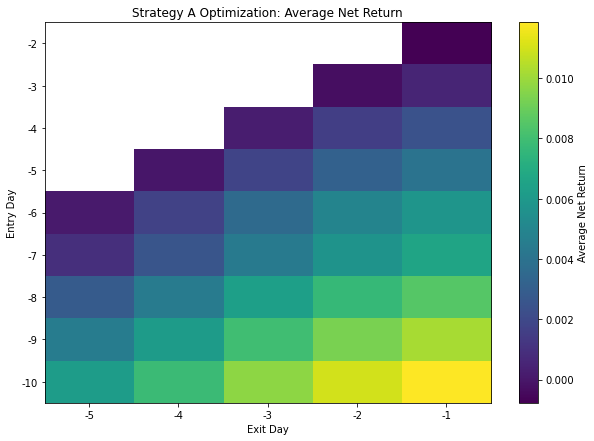

In [52]:
heatmap_avg = pre_div_optimization.pivot(
    index="entry_day",
    columns="exit_day",
    values="avg_net_return",
)

plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_avg,
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="Average Net Return")

plt.xticks(
    ticks=np.arange(len(heatmap_avg.columns)),
    labels=heatmap_avg.columns,
)

plt.yticks(
    ticks=np.arange(len(heatmap_avg.index)),
    labels=heatmap_avg.index,
)

plt.title("Strategy A Optimization: Average Net Return")
plt.xlabel("Exit Day")
plt.ylabel("Entry Day")
plt.show()

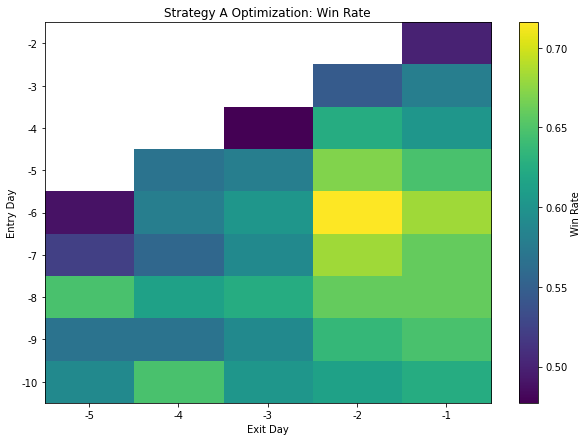

In [53]:
heatmap_win = pre_div_optimization.pivot(
    index="entry_day",
    columns="exit_day",
    values="win_rate",
)

plt.figure(figsize=(10, 7))

plt.imshow(
    heatmap_win,
    aspect="auto",
    origin="lower",
)

plt.colorbar(label="Win Rate")

plt.xticks(
    ticks=np.arange(len(heatmap_win.columns)),
    labels=heatmap_win.columns,
)

plt.yticks(
    ticks=np.arange(len(heatmap_win.index)),
    labels=heatmap_win.index,
)

plt.title("Strategy A Optimization: Win Rate")
plt.xlabel("Exit Day")
plt.ylabel("Entry Day")
plt.show()

## Premium 分組實驗

In [54]:
def run_premium_filter_experiment(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """
    Test entry premium filters.
    """

    df = trades.copy()

    premium_median = df["entry_premium"].median()
    premium_q25 = df["entry_premium"].quantile(0.25)
    premium_q75 = df["entry_premium"].quantile(0.75)

    experiments = {
        "all": df,
        "entry_premium_below_median": df[df["entry_premium"] <= premium_median],
        "entry_premium_above_median": df[df["entry_premium"] > premium_median],
        "entry_premium_bottom_25pct": df[df["entry_premium"] <= premium_q25],
        "entry_premium_top_25pct": df[df["entry_premium"] >= premium_q75],
        "entry_premium_not_too_expensive": df[df["entry_premium"] <= premium_q75],
    }

    rows = []

    for name, tmp in experiments.items():
        summary = summarize_event_trades(tmp)

        row = {
            "experiment": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["avg_net_return", "median_net_return"],
        ascending=[False, False],
    ).reset_index(drop=True)


premium_filter_result = run_premium_filter_experiment(baseline_trades)

premium_filter_result

,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,entry_premium_top_25pct,20.0,0.019656,0.008740,0.700000,0.393113,0.035517,-0.034933,0.113074,6.236258
1,entry_premium_above_median,39.0,0.014283,0.012260,0.641026,0.557042,0.034361,-0.069830,0.113074,3.206836
2,all,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
3,entry_premium_below_median,40.0,0.010109,0.006073,0.625000,0.404372,0.030175,-0.067980,0.060900,2.343762
4,entry_premium_bottom_25pct,20.0,0.009896,0.006073,0.600000,0.197927,0.030283,-0.054032,0.060900,2.317098
5,entry_premium_not_too_expensive,59.0,0.009632,0.010591,0.610169,0.568301,0.030865,-0.069830,0.060900,2.188252


## Dividend Yield 分組實驗

In [55]:
def run_dividend_yield_filter_experiment(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """
    Test dividend yield filters.
    """

    df = trades.copy()

    yield_median = df["dividend_yield_on_entry"].median()
    yield_q25 = df["dividend_yield_on_entry"].quantile(0.25)
    yield_q75 = df["dividend_yield_on_entry"].quantile(0.75)

    experiments = {
        "all": df,
        "dividend_yield_above_median": df[df["dividend_yield_on_entry"] >= yield_median],
        "dividend_yield_below_median": df[df["dividend_yield_on_entry"] < yield_median],
        "dividend_yield_top_25pct": df[df["dividend_yield_on_entry"] >= yield_q75],
        "dividend_yield_bottom_25pct": df[df["dividend_yield_on_entry"] <= yield_q25],
    }

    rows = []

    for name, tmp in experiments.items():
        summary = summarize_event_trades(tmp)

        row = {
            "experiment": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["avg_net_return", "median_net_return"],
        ascending=[False, False],
    ).reset_index(drop=True)


dividend_yield_filter_result = run_dividend_yield_filter_experiment(
    baseline_trades
)

dividend_yield_filter_result

,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,dividend_yield_above_median,44.0,0.012423,0.006458,0.613636,0.546610,0.027116,-0.034933,0.113074,4.107457
1,all,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
2,dividend_yield_below_median,44.0,0.011271,0.013244,0.636364,0.495920,0.034593,-0.069830,0.077921,2.242597
3,dividend_yield_bottom_25pct,22.0,0.009969,0.004059,0.545455,0.219309,0.034788,-0.067980,0.060900,2.070359
4,dividend_yield_top_25pct,22.0,0.007280,-0.000816,0.454545,0.160169,0.030616,-0.034933,0.113074,2.275681


## Volume Filter 實驗

In [56]:
def run_volume_filter_experiment(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """
    Test entry volume ratio filters.
    """

    df = trades.copy()

    vol_median = df["entry_volume_ratio"].median()
    vol_q75 = df["entry_volume_ratio"].quantile(0.75)

    experiments = {
        "all": df,
        "entry_volume_above_median": df[df["entry_volume_ratio"] >= vol_median],
        "entry_volume_below_median": df[df["entry_volume_ratio"] < vol_median],
        "entry_volume_top_25pct": df[df["entry_volume_ratio"] >= vol_q75],
    }

    rows = []

    for name, tmp in experiments.items():
        summary = summarize_event_trades(tmp)

        row = {
            "experiment": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["avg_net_return", "median_net_return"],
        ascending=[False, False],
    ).reset_index(drop=True)


volume_filter_result = run_volume_filter_experiment(baseline_trades)

volume_filter_result

,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,entry_volume_top_25pct,22.0,0.013392,0.004679,0.500000,0.294619,0.039343,-0.06983,0.113074,2.555860
1,entry_volume_below_median,44.0,0.013256,0.009191,0.727273,0.583246,0.027053,-0.06798,0.058451,3.707221
2,all,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.06983,0.113074,2.813089
3,entry_volume_above_median,44.0,0.010438,0.000477,0.522727,0.459284,0.034593,-0.06983,0.113074,2.277345


## 標的篩選實驗

In [57]:
def run_symbol_filter_experiment(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """
    Test symbol group filters.
    """

    df = trades.copy()

    experiments = {
        "all": df,
        "exclude_0056_00713": df[~df["symbol"].isin(["0056", "00713"])],
        "only_00929": df[df["symbol"].isin(["00929"])],
        "high_alpha_symbols_00878_00919_00929": df[df["symbol"].isin(["00878", "00919", "00929"])],
        "old_large_symbols_0056_00713": df[df["symbol"].isin(["0056", "00713"])],
    }

    rows = []

    for name, tmp in experiments.items():
        summary = summarize_event_trades(tmp)

        row = {
            "experiment": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["avg_net_return", "median_net_return"],
        ascending=[False, False],
    ).reset_index(drop=True)


symbol_filter_result = run_symbol_filter_experiment(baseline_trades)

symbol_filter_result

,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,exclude_0056_00713,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
1,high_alpha_symbols_00878_00919_00929,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
2,only_00929,24.0,0.012791,0.006339,0.583333,0.306977,0.036106,-0.067980,0.077921,2.498234
3,all,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
4,old_large_symbols_0056_00713,34.0,0.009860,0.005209,0.558824,0.335245,0.027761,-0.034933,0.113074,3.015221


## Market Regime Filter 實驗

In [58]:
benchmark_symbol = "0050"

benchmark = (
    panel_all[panel_all["symbol"] == benchmark_symbol]
    .sort_values("date")
    .copy()
)

benchmark["bench_ret_20"] = benchmark["adj_close"].pct_change(20)
benchmark["bench_ret_60"] = benchmark["adj_close"].pct_change(60)
benchmark["bench_ma_60"] = benchmark["adj_close"].rolling(60).mean()
benchmark["bench_ma_ratio_60"] = benchmark["adj_close"] / benchmark["bench_ma_60"] - 1

benchmark_features = benchmark[
    [
        "date",
        "bench_ret_20",
        "bench_ret_60",
        "bench_ma_ratio_60",
    ]
].copy()

benchmark_features = benchmark_features.rename(
    columns={"date": "entry_date"}
)

trades_with_regime = baseline_trades.merge(
    benchmark_features,
    on="entry_date",
    how="left",
)

trades_with_regime.head()

,event_id,symbol,etf_name,ex_date,dividend,entry_day,exit_day,holding_days,entry_date,exit_date,...,net_return,entry_premium,exit_premium,premium_change_entry_to_exit,entry_volume_ratio,dividend_yield_on_entry,entry_year,bench_ret_20,bench_ret_60,bench_ma_ratio_60
0,0056_20161026,0056,元大高股息,2016-10-26,1.30,-10,-1,9,2016-10-12,2016-10-25,...,0.013618,0.0016,0.0088,0.0072,0.932839,0.052062,2016,0.026278,0.067766,0.031618
1,0056_20171030,0056,元大高股息,2017-10-30,0.95,-10,-1,9,2017-10-16,2017-10-27,...,-0.001221,-0.0042,0.0053,0.0095,1.395515,0.036012,2017,0.026732,0.030552,0.029153
2,0056_20181023,0056,元大高股息,2018-10-23,1.45,-10,-1,9,2018-10-08,2018-10-22,...,-0.034933,0.0191,0.0114,-0.0077,10.685149,0.054307,2018,-0.039352,0.004104,-0.027725
3,0056_20191023,0056,元大高股息,2019-10-23,1.80,-10,-1,9,2019-10-07,2019-10-22,...,0.019864,0.0018,0.0028,0.0010,6.258409,0.063336,2019,0.040170,0.057416,0.035613
4,0056_20201028,0056,元大高股息,2020-10-28,1.60,-10,-1,9,2020-10-14,2020-10-27,...,-0.003281,0.0027,0.0037,0.0010,0.664880,0.053800,2020,0.033414,0.105712,0.032281


In [59]:
def run_market_regime_filter_experiment(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """
    Test market regime filters based on 0050 trend.
    """

    df = trades.copy()

    experiments = {
        "all": df,
        "bench_ret_20_positive": df[df["bench_ret_20"] > 0],
        "bench_ret_20_negative": df[df["bench_ret_20"] <= 0],
        "bench_ret_60_positive": df[df["bench_ret_60"] > 0],
        "bench_ret_60_negative": df[df["bench_ret_60"] <= 0],
        "bench_above_ma60": df[df["bench_ma_ratio_60"] > 0],
        "bench_below_ma60": df[df["bench_ma_ratio_60"] <= 0],
    }

    rows = []

    for name, tmp in experiments.items():
        summary = summarize_event_trades(tmp)

        row = {
            "experiment": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["avg_net_return", "median_net_return"],
        ascending=[False, False],
    ).reset_index(drop=True)


market_regime_filter_result = run_market_regime_filter_experiment(
    trades_with_regime
)

market_regime_filter_result

,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,bench_below_ma60,27.0,0.014917,0.009768,0.555556,0.402752,0.036358,-0.051521,0.113074,3.209554
1,bench_ret_60_negative,23.0,0.013125,0.010591,0.652174,0.301865,0.037982,-0.069830,0.113074,2.671945
2,bench_ret_20_positive,62.0,0.011897,0.012090,0.677419,0.737623,0.027804,-0.069830,0.058264,2.989221
3,all,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
4,bench_ret_20_negative,26.0,0.011727,-0.001104,0.500000,0.304907,0.037919,-0.051521,0.113074,2.493236
5,bench_ret_60_positive,65.0,0.011395,0.006949,0.615385,0.740665,0.028316,-0.067980,0.077921,2.877692
6,bench_above_ma60,61.0,0.010488,0.007712,0.655738,0.639778,0.028392,-0.069830,0.058264,2.629075


## 整合所有 Alpha 實驗結果

In [60]:
def add_experiment_family(df: pd.DataFrame, family: str) -> pd.DataFrame:
    tmp = df.copy()
    tmp.insert(0, "family", family)
    return tmp


all_alpha_experiments = pd.concat(
    [
        add_experiment_family(premium_filter_result, "entry_premium_filter"),
        add_experiment_family(dividend_yield_filter_result, "dividend_yield_filter"),
        add_experiment_family(volume_filter_result, "entry_volume_filter"),
        add_experiment_family(symbol_filter_result, "symbol_filter"),
        add_experiment_family(market_regime_filter_result, "market_regime_filter"),
    ],
    ignore_index=True,
)

all_alpha_experiments = all_alpha_experiments.sort_values(
    ["avg_net_return", "median_net_return", "win_rate"],
    ascending=[False, False, False],
).reset_index(drop=True)

all_alpha_experiments

,family,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,entry_premium_filter,entry_premium_top_25pct,20.0,0.019656,0.008740,0.700000,0.393113,0.035517,-0.034933,0.113074,6.236258
1,market_regime_filter,bench_below_ma60,27.0,0.014917,0.009768,0.555556,0.402752,0.036358,-0.051521,0.113074,3.209554
2,entry_premium_filter,entry_premium_above_median,39.0,0.014283,0.012260,0.641026,0.557042,0.034361,-0.069830,0.113074,3.206836
3,entry_volume_filter,entry_volume_top_25pct,22.0,0.013392,0.004679,0.500000,0.294619,0.039343,-0.069830,0.113074,2.555860
4,entry_volume_filter,entry_volume_below_median,44.0,0.013256,0.009191,0.727273,0.583246,0.027053,-0.067980,0.058451,3.707221
5,market_regime_filter,bench_ret_60_negative,23.0,0.013125,0.010591,0.652174,0.301865,0.037982,-0.069830,0.113074,2.671945
6,symbol_filter,exclude_0056_00713,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
7,symbol_filter,high_alpha_symbols_00878_00919_00929,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
8,symbol_filter,only_00929,24.0,0.012791,0.006339,0.583333,0.306977,0.036106,-0.067980,0.077921,2.498234
9,dividend_yield_filter,dividend_yield_above_median,44.0,0.012423,0.006458,0.613636,0.546610,0.027116,-0.034933,0.113074,4.107457


## 找候選策略

In [61]:
candidate_alpha_experiments = all_alpha_experiments[
    all_alpha_experiments["trade_count"] >= 20
].copy()

candidate_alpha_experiments = candidate_alpha_experiments.sort_values(
    ["avg_net_return", "median_net_return", "profit_factor"],
    ascending=[False, False, False],
).reset_index(drop=True)

candidate_alpha_experiments.head(20)

,family,experiment,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,entry_premium_filter,entry_premium_top_25pct,20.0,0.019656,0.008740,0.700000,0.393113,0.035517,-0.034933,0.113074,6.236258
1,market_regime_filter,bench_below_ma60,27.0,0.014917,0.009768,0.555556,0.402752,0.036358,-0.051521,0.113074,3.209554
2,entry_premium_filter,entry_premium_above_median,39.0,0.014283,0.012260,0.641026,0.557042,0.034361,-0.069830,0.113074,3.206836
3,entry_volume_filter,entry_volume_top_25pct,22.0,0.013392,0.004679,0.500000,0.294619,0.039343,-0.069830,0.113074,2.555860
4,entry_volume_filter,entry_volume_below_median,44.0,0.013256,0.009191,0.727273,0.583246,0.027053,-0.067980,0.058451,3.707221
5,market_regime_filter,bench_ret_60_negative,23.0,0.013125,0.010591,0.652174,0.301865,0.037982,-0.069830,0.113074,2.671945
6,symbol_filter,exclude_0056_00713,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
7,symbol_filter,high_alpha_symbols_00878_00919_00929,54.0,0.013098,0.012090,0.666667,0.707285,0.032924,-0.069830,0.077921,2.730802
8,symbol_filter,only_00929,24.0,0.012791,0.006339,0.583333,0.306977,0.036106,-0.067980,0.077921,2.498234
9,dividend_yield_filter,dividend_yield_above_median,44.0,0.012423,0.006458,0.613636,0.546610,0.027116,-0.034933,0.113074,4.107457


## 檢查最佳策略是否靠少數事件

In [62]:
def stress_test_extreme_events(
    trades: pd.DataFrame,
    return_col: str = "net_return",
) -> pd.DataFrame:
    """
    Check whether the strategy depends on a few extreme winners.
    """

    df = trades.sort_values(return_col, ascending=False).copy()

    test_sets = {
        "all_trades": df,
        "without_best_1": df.iloc[1:],
        "without_best_3": df.iloc[3:],
        "without_best_5": df.iloc[5:],
        "without_worst_1": df.iloc[:-1],
        "without_worst_3": df.iloc[:-3],
    }

    rows = []

    for name, tmp in test_sets.items():
        summary = summarize_event_trades(tmp, return_col=return_col)

        row = {
            "test": name,
            **summary.to_dict(),
        }

        rows.append(row)

    return pd.DataFrame(rows)


baseline_stress_test = stress_test_extreme_events(baseline_trades)

baseline_stress_test

,test,trade_count,avg_net_return,median_net_return,win_rate,total_net_return_sum,std_net_return,min_net_return,max_net_return,profit_factor
0,all_trades,88.0,0.011847,0.007752,0.625000,1.042530,0.030906,-0.069830,0.113074,2.813089
1,without_best_1,87.0,0.010683,0.007712,0.620690,0.929456,0.029083,-0.069830,0.077921,2.616439
2,without_best_3,85.0,0.009302,0.006949,0.611765,0.790635,0.027931,-0.069830,0.058451,2.375013
3,without_best_5,83.0,0.008120,0.005966,0.602410,0.673920,0.027186,-0.069830,0.055351,2.172031
4,without_worst_1,87.0,0.012786,0.007792,0.632184,1.112360,0.029797,-0.067980,0.113074,3.201944
5,without_worst_3,85.0,0.014522,0.009768,0.647059,1.234372,0.027841,-0.051521,0.113074,4.221560


## 輸出策略研究結果

In [63]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "research"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_trades_path = OUTPUT_DIR / "strategy_A_baseline_trades.csv"
optimization_path = OUTPUT_DIR / "strategy_A_holding_period_optimization.csv"
alpha_experiments_path = OUTPUT_DIR / "strategy_A_alpha_experiments.csv"
candidate_alpha_path = OUTPUT_DIR / "strategy_A_candidate_alpha_experiments.csv"

baseline_trades.to_csv(
    baseline_trades_path,
    index=False,
    encoding="utf-8-sig",
)

pre_div_optimization.to_csv(
    optimization_path,
    index=False,
    encoding="utf-8-sig",
)

all_alpha_experiments.to_csv(
    alpha_experiments_path,
    index=False,
    encoding="utf-8-sig",
)

candidate_alpha_experiments.to_csv(
    candidate_alpha_path,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", baseline_trades_path)
print("Saved:", optimization_path)
print("Saved:", alpha_experiments_path)
print("Saved:", candidate_alpha_path)

Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\strategy_A_baseline_trades.csv
Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\strategy_A_holding_period_optimization.csv
Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\strategy_A_alpha_experiments.csv
Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\strategy_A_candidate_alpha_experiments.csv


# 對整個假設做檢定

## 產生單一事件的 matched random windows

In [76]:
def generate_matched_random_windows_for_event(
    panel_all: pd.DataFrame,
    event_summary: pd.DataFrame,
    symbol: str,
    event_year: int,
    holding_days: int,
    n_samples: int = 500,
    buffer_days: int = 30,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    random_state: int = 42,
) -> pd.Series:
    """
    Generate matched non-event window returns for one ETF and one event year.

    Matching rules:
    1. Same ETF symbol
    2. Same calendar year
    3. Same holding days
    4. Exclude windows near ex-dividend dates
    """

    rng = np.random.default_rng(random_state)

    p = (
        panel_all[
            (panel_all["symbol"] == symbol)
            & (panel_all["date"].dt.year == event_year)
        ]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    if p.empty:
        return pd.Series(dtype=float)

    event_dates = pd.to_datetime(
        event_summary.loc[
            event_summary["symbol"] == symbol,
            "ex_date",
        ]
    ).dropna()

    valid_returns = []

    max_start = len(p) - holding_days - 1

    if max_start <= 0:
        return pd.Series(dtype=float)

    for _ in range(n_samples):
        start_idx = rng.integers(0, max_start)
        end_idx = start_idx + holding_days

        start_date = p.loc[start_idx, "date"]
        end_date = p.loc[end_idx, "date"]

        # 排除靠近除息日的窗口，避免把事件效果混進 placebo
        near_event = False

        for ex_date in event_dates:
            if abs((start_date - ex_date).days) <= buffer_days:
                near_event = True
                break

            if abs((end_date - ex_date).days) <= buffer_days:
                near_event = True
                break

        if near_event:
            continue

        start_price = p.loc[start_idx, price_col]
        end_price = p.loc[end_idx, price_col]

        if pd.isna(start_price) or pd.isna(end_price) or start_price == 0:
            continue

        raw_return = end_price / start_price - 1
        net_return = raw_return - 2 * fee_rate
        daily_net_return = net_return / holding_days

        valid_returns.append(daily_net_return)

    return pd.Series(valid_returns)

## 對每一筆事件建立 matched benchmark

In [78]:
def build_event_vs_matched_placebo_table(
    event_data: pd.DataFrame,
    event_summary: pd.DataFrame,
    panel_all: pd.DataFrame,
    entry_day: int,
    exit_day: int,
    price_col: str = "adj_close",
    fee_rate: float = 0.0008,
    n_samples: int = 500,
    buffer_days: int = 30,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Compare each event-window daily return with matched non-event windows.

    Output one row per event.
    """

    holding_days = exit_day - entry_day

    actual_trades = calculate_event_trade_return_enriched(
        event_data=event_data,
        price_col=price_col,
        entry_day=entry_day,
        exit_day=exit_day,
        fee_rate=fee_rate,
    )

    rows = []

    for i, trade in actual_trades.iterrows():
        symbol = trade["symbol"]
        entry_year = pd.to_datetime(trade["entry_date"]).year

        actual_daily_return = trade["net_return"] / holding_days

        random_returns = generate_matched_random_windows_for_event(
            panel_all=panel_all,
            event_summary=event_summary,
            symbol=symbol,
            event_year=entry_year,
            holding_days=holding_days,
            n_samples=n_samples,
            buffer_days=buffer_days,
            price_col=price_col,
            fee_rate=fee_rate,
            random_state=random_state + i,
        )

        if random_returns.empty:
            continue

        placebo_mean = random_returns.mean()
        placebo_median = random_returns.median()

        row = {
            "event_id": trade["event_id"],
            "symbol": symbol,
            "entry_date": trade["entry_date"],
            "exit_date": trade["exit_date"],
            "ex_date": trade["ex_date"],
            "entry_day": entry_day,
            "exit_day": exit_day,
            "holding_days": holding_days,
            "actual_net_return": trade["net_return"],
            "actual_daily_return": actual_daily_return,
            "matched_placebo_mean_daily_return": placebo_mean,
            "matched_placebo_median_daily_return": placebo_median,
            "event_excess_daily_return": actual_daily_return - placebo_mean,
            "random_sample_count": len(random_returns),
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [79]:
matched_placebo_table = build_event_vs_matched_placebo_table(
    event_data=event_data,
    event_summary=event_summary,
    panel_all=panel_all,
    entry_day=-10,
    exit_day=-1,
    price_col="adj_close",
    fee_rate=0.0008,
    n_samples=1000,
    buffer_days=30,
    random_state=42,
)

matched_placebo_table.head()

,event_id,symbol,entry_date,exit_date,ex_date,entry_day,exit_day,holding_days,actual_net_return,actual_daily_return,matched_placebo_mean_daily_return,matched_placebo_median_daily_return,event_excess_daily_return,random_sample_count
0,0056_20161026,0056,2016-10-12,2016-10-25,2016-10-26,-10,-1,9,0.013618,0.001513,0.000657,0.000561,0.000856,768
1,0056_20171030,0056,2017-10-16,2017-10-27,2017-10-30,-10,-1,9,-0.001221,-0.000136,0.000434,0.000585,-0.000570,778
2,0056_20181023,0056,2018-10-08,2018-10-22,2018-10-23,-10,-1,9,-0.034933,-0.003881,0.000036,0.000079,-0.003917,780
3,0056_20191023,0056,2019-10-07,2019-10-22,2019-10-23,-10,-1,9,0.019864,0.002207,0.001040,0.001540,0.001167,755
4,0056_20201028,0056,2020-10-14,2020-10-27,2020-10-28,-10,-1,9,-0.003281,-0.000365,0.000198,0.000572,-0.000562,795


## 對 event excess daily return 做 t 檢定

In [80]:
matched_placebo_significance = summarize_return_significance(
    matched_placebo_table["event_excess_daily_return"],
    alternative="greater",
)

matched_placebo_significance.to_frame("matched_placebo_test")

,matched_placebo_test
count,66.000000
mean,0.000932
median,0.000414
std,0.003300
t_stat,2.293656
p_value,0.012526
win_rate,0.560606
sharpe_like,0.282330


## 整理結果

In [81]:
matched_placebo_summary = pd.Series({
    "event_count": len(matched_placebo_table),
    "actual_daily_return_mean": matched_placebo_table["actual_daily_return"].mean(),
    "placebo_daily_return_mean": matched_placebo_table["matched_placebo_mean_daily_return"].mean(),
    "excess_daily_return_mean": matched_placebo_table["event_excess_daily_return"].mean(),
    "excess_daily_return_median": matched_placebo_table["event_excess_daily_return"].median(),
    "excess_win_rate": (matched_placebo_table["event_excess_daily_return"] > 0).mean(),
    "avg_random_sample_count": matched_placebo_table["random_sample_count"].mean(),
})

matched_placebo_summary.to_frame("summary")

,summary
event_count,66.000000
actual_daily_return_mean,0.001350
placebo_daily_return_mean,0.000419
excess_daily_return_mean,0.000932
excess_daily_return_median,0.000414
excess_win_rate,0.560606
avg_random_sample_count,342.136364


In [82]:
holding_windows = [
    (-5, -1),
    (-10, -1),
    (-20, -1),
    (-30, -1),
    (-50, -1),
]

matched_window_results = []

for entry_day, exit_day in holding_windows:
    table = build_event_vs_matched_placebo_table(
        event_data=event_data,
        event_summary=event_summary,
        panel_all=panel_all,
        entry_day=entry_day,
        exit_day=exit_day,
        price_col="adj_close",
        fee_rate=0.0008,
        n_samples=1000,
        buffer_days=30,
        random_state=42,
    )

    sig = summarize_return_significance(
        table["event_excess_daily_return"],
        alternative="greater",
    )

    row = {
        "entry_day": entry_day,
        "exit_day": exit_day,
        "holding_days": exit_day - entry_day,
        "event_count": len(table),
        "actual_daily_return_mean": table["actual_daily_return"].mean(),
        "placebo_daily_return_mean": table["matched_placebo_mean_daily_return"].mean(),
        "excess_daily_return_mean": table["event_excess_daily_return"].mean(),
        "excess_daily_return_median": table["event_excess_daily_return"].median(),
        "excess_win_rate": (table["event_excess_daily_return"] > 0).mean(),
        "t_stat": sig["t_stat"],
        "p_value": sig["p_value"],
    }

    matched_window_results.append(row)

matched_window_comparison = pd.DataFrame(matched_window_results)

matched_window_comparison.sort_values(
    ["t_stat", "excess_daily_return_mean"],
    ascending=[False, False],
)

,entry_day,exit_day,holding_days,event_count,actual_daily_return_mean,placebo_daily_return_mean,excess_daily_return_mean,excess_daily_return_median,excess_win_rate,t_stat,p_value
1,-10,-1,9,66,0.001350,0.000419,0.000932,0.000414,0.560606,2.293656,0.012526
0,-5,-1,4,77,0.001053,0.000407,0.000647,0.000900,0.623377,1.134089,0.130161
2,-20,-1,19,63,0.001029,0.000739,0.000290,0.000388,0.571429,0.862853,0.195772
3,-30,-1,29,32,0.001132,0.000885,0.000247,0.000224,0.500000,0.832826,0.205657
4,-50,-1,49,69,0.000737,0.000814,-0.000077,0.000033,0.521739,-0.489206,0.686865
